# Food Insecurity in the United States

This notebook analyzes U.S. food insecurity using USDA ERS data, focusing on state differences and national patterns by education, employment, and disability status. It also uses World Bank undernourishment data for limited international context.

## 1. Introduction

Food insecurity is an important public health and economic issue in the U.S. This project uses USDA Economic Research Service data to analyze food insecurity by state, education, employment, and disability status.

The states chosen for comparison are California, Texas, Iowa, New York, and Louisiana. These states were selected because they are personally meaningful to me through family and other significant ties.

### Goals

The goals of this project are to:

1. Practice using Python and pandas.
2. Clean, inspect, prepare, and analyze real-world data.
3. Communicate findings and limitations.

### Data Questions

This analysis focuses on these questions:

1. How do food insecurity rates differ among California, Texas, Iowa, New York, and Louisiana?
2. How do selected states compare with the U.S. overall?
3. How does food insecurity vary by education level in the U.S.?
4. How does food insecurity vary by employment group in the U.S.?
5. How does food insecurity vary by disability status in the U.S.?
6. How does the U.S. compare with Canada and Mexico on undernourishment, and what World Bank metadata can be used to interpret that comparison?

## 2. Data Sources

The primary data source is USDA ERS Food Security in the U.S. data. This project uses state-level data and education/employment/disability data. World Bank undernourishment data is used as a secondary source for limited international context.

## 3. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 4. Load the Data

#### Step 1: Add Path Setup

In [2]:
project_root = Path('..')

usda_dir = project_root / 'data' / 'raw' / 'usda_ers_food_security' / 'foodsecurity_csv_datafiles'
world_bank_dir = project_root / 'data' / 'raw' / 'world_bank_undernourishment'

#### Step 2: Load USDA Files

In [3]:
state_df = pd.read_csv(usda_dir / 'foodsecurity-state-2024.csv', encoding='cp1252')
educ_emp_dis_df = pd.read_csv(usda_dir / 'foodsecurity-educ-emp-dis-2024.csv', encoding='cp1252')

#### Step 3: Load World Bank Files

In [4]:
wb_undernourishment_df = pd.read_csv(
    world_bank_dir / 'API_SN.ITK.DEFC.ZS_DS2_en_csv_v2_4749.csv',
    skiprows=4
)

wb_country_metadata_df = pd.read_csv(
    world_bank_dir / 'Metadata_Country_API_SN.ITK.DEFC.ZS_DS2_en_csv_v2_4749.csv'
)

wb_indicator_metadata_df = pd.read_csv(
    world_bank_dir / 'Metadata_Indicator_API_SN.ITK.DEFC.ZS_DS2_en_csv_v2_4749.csv'
)

## 5. Inspect the Data

### 5.1 Inspect `state_df`

In [5]:
state_df.head()

,Year,State,Food insecurity prevalence,Food insecurity–margin of error,Very low food security prevalence,Very low food security–margin of error
0,2006–2008,U.S. total,12.2,0.25,4.6,0.18
1,2006–2008,AK,11.6,1.66,4.4,1.31
2,2006–2008,AL,13.3,1.66,5.4,1.02
3,2006–2008,AR,15.9,3.19,5.6,1.50
4,2006–2008,AZ,13.2,1.51,4.9,0.84


In [6]:
state_df.shape

(884, 6)

In [7]:
state_df.columns

Index(['Year', 'State', 'Food insecurity prevalence',
       'Food insecurity–margin of error', 'Very low food security prevalence',
       'Very low food security–margin of error '],
      dtype='str')

In [8]:
state_df.isna().sum()

Year                                       0
State                                      0
Food insecurity prevalence                 0
Food insecurity–margin of error            0
Very low food security prevalence          0
Very low food security–margin of error     0
dtype: int64

In [9]:
state_df.duplicated().sum()

np.int64(0)

In [10]:
state_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 884 entries, 0 to 883
Data columns (total 6 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Year                                     884 non-null    str    
 1   State                                    884 non-null    str    
 2   Food insecurity prevalence               884 non-null    float64
 3   Food insecurity–margin of error          884 non-null    float64
 4   Very low food security prevalence        884 non-null    float64
 5   Very low food security–margin of error   884 non-null    float64
dtypes: float64(4), str(2)
memory usage: 41.6 KB


In [11]:
state_df.describe()

,Food insecurity prevalence,Food insecurity–margin of error,Very low food security prevalence,Very low food security–margin of error
count,884.000000,884.000000,884.000000,884.000000
mean,12.536991,1.533518,4.915498,0.946459
std,2.658856,0.466832,1.171112,0.293564
min,5.400000,0.190000,1.800000,0.100000
25%,10.600000,1.250000,4.100000,0.760000
50%,12.400000,1.520000,4.800000,0.930000
75%,14.325000,1.800000,5.700000,1.120000
max,22.000000,3.620000,9.000000,2.240000


In [12]:
state_df['Year'].value_counts()

Year
2006–2008    52
2007–2009    52
2008–2010    52
2009–2011    52
2010–2012    52
2011–2013    52
2012–2014    52
2013–2015    52
2014–2016    52
2015–2017    52
2016–2018    52
2017–2019    52
2018–2020    52
2019–2021    52
2020–2022    52
2021–2023    52
2022–2024    52
Name: count, dtype: int64

In [13]:
state_df['State'].value_counts()

State
AK            17
AL            17
AR            17
AZ            17
CA            17
CO            17
CT            17
DC            17
DE            17
FL            17
GA            17
HI            17
IA            17
ID            17
IL            17
IN            17
KS            17
KY            17
LA            17
MA            17
MD            17
ME            17
MI            17
MN            17
MO            17
MS            17
MT            17
NC            17
ND            17
NE            17
NH            17
NJ            17
NM            17
NV            17
NY            17
OH            17
OK            17
OR            17
PA            17
RI            17
SC            17
SD            17
TN            17
TX            17
UT            17
VA            17
VT            17
WA            17
WI            17
WV            17
WY            17
U.S.          16
U.S. total     1
Name: count, dtype: int64

### 5.2 Inspect `educ_emp_dis_df`

In [14]:
educ_emp_dis_df.head()

,Year,Category,Subcategory,Sub-subcategory,Total,"Food insecure-1,000",Food insecure-percent,Food insecure-share,"Very low food security-1,000",Very low food security-percent,Very low food security-share
0,2017,All households,NaN,NaN,127272,15018,11.8,100.0,5757,4.5,100.0
1,2017,All households,Employment,Full-time,83681,7871,9.4,52.4,2448,2.9,42.5
2,2017,All households,Employment,Retired,26903,2002,7.4,13.3,861,3.2,15.0
3,2017,All households,Employment,Part-time non-economic reasons,5673,1055,18.6,7.0,421,7.4,7.3
4,2017,All households,Employment,Part-time economic reasons,1162,447,38.5,3.0,168,14.4,2.9


In [15]:
educ_emp_dis_df.shape

(128, 11)

In [16]:
educ_emp_dis_df.columns

Index(['Year', 'Category', 'Subcategory', 'Sub-subcategory', 'Total',
       'Food insecure-1,000', 'Food insecure-percent', 'Food insecure-share',
       'Very low food security-1,000', 'Very low food security-percent',
       'Very low food security-share'],
      dtype='str')

In [17]:
educ_emp_dis_df.isna().sum()

Year                              0
Category                          0
Subcategory                       8
Sub-subcategory                   8
Total                             0
Food insecure-1,000               0
Food insecure-percent             0
Food insecure-share               0
Very low food security-1,000      0
Very low food security-percent    0
Very low food security-share      0
dtype: int64

In [18]:
educ_emp_dis_df.duplicated().sum()

np.int64(0)

In [19]:
educ_emp_dis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            128 non-null    int64  
 1   Category                        128 non-null    str    
 2   Subcategory                     120 non-null    str    
 3   Sub-subcategory                 120 non-null    str    
 4   Total                           128 non-null    int64  
 5   Food insecure-1,000             128 non-null    int64  
 6   Food insecure-percent           128 non-null    float64
 7   Food insecure-share             128 non-null    float64
 8   Very low food security-1,000    128 non-null    int64  
 9   Very low food security-percent  128 non-null    float64
 10  Very low food security-share    128 non-null    float64
dtypes: float64(4), int64(4), str(3)
memory usage: 11.1 KB


In [20]:
educ_emp_dis_df.describe()

,Year,Total,"Food insecure-1,000",Food insecure-percent,Food insecure-share,"Very low food security-1,000",Very low food security-percent,Very low food security-share
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,2020.500000,32748.867188,3860.304688,20.905469,25.000781,1489.859375,9.170312,24.999219
std,2.300291,39303.864929,4004.054613,12.230267,25.490444,1474.454458,6.458960,24.234025
min,2017.000000,796.000000,282.000000,4.500000,1.700000,128.000000,1.500000,2.100000
25%,2018.750000,5320.000000,1054.500000,10.125000,6.975000,437.500000,3.575000,7.250000
50%,2020.500000,11343.500000,2175.000000,18.400000,14.550000,966.500000,7.300000,15.450000
75%,2022.250000,41312.500000,4953.000000,30.425000,33.750000,1991.000000,13.525000,34.225000
max,2024.000000,134062.000000,18341.000000,49.000000,100.000000,7202.000000,25.400000,100.000000


In [21]:
educ_emp_dis_df['Year'].value_counts()

Year
2017    16
2018    16
2019    16
2020    16
2021    16
2022    16
2023    16
2024    16
Name: count, dtype: int64

In [22]:
educ_emp_dis_df['Category'].value_counts()

Category
All households    128
Name: count, dtype: int64

In [23]:
educ_emp_dis_df['Subcategory'].value_counts()

Subcategory
Employment           56
Education            32
Disability status    32
Name: count, dtype: int64

In [24]:
educ_emp_dis_df['Sub-subcategory'].value_counts()

Sub-subcategory
Full-time                               8
Retired                                 8
Part-time non-economic reasons          8
Part-time economic reasons              8
Unemployed                              8
Disabled                                8
Not in labor force                      8
Less than high school                   8
High School                             8
Some College                            8
College or more                         8
Not in labor force due to disability    8
Other disability among adults 18-64     8
Other disability among adults 65+       8
No adult with disabilities              8
Name: count, dtype: int64

In [25]:
educ_emp_dis_df.loc[
    educ_emp_dis_df['Subcategory'] == 'Employment',
    'Sub-subcategory'
].value_counts()

Sub-subcategory
Full-time                         8
Retired                           8
Part-time non-economic reasons    8
Part-time economic reasons        8
Unemployed                        8
Disabled                          8
Not in labor force                8
Name: count, dtype: int64

In [26]:
educ_emp_dis_df.loc[
    educ_emp_dis_df['Subcategory'] == 'Employment',
    'Sub-subcategory'
].value_counts()

Sub-subcategory
Full-time                         8
Retired                           8
Part-time non-economic reasons    8
Part-time economic reasons        8
Unemployed                        8
Disabled                          8
Not in labor force                8
Name: count, dtype: int64

In [27]:
educ_emp_dis_df.loc[
    educ_emp_dis_df['Subcategory'] == 'Disability status',
    'Sub-subcategory'
].value_counts()

Sub-subcategory
Not in labor force due to disability    8
Other disability among adults 18-64     8
Other disability among adults 65+       8
No adult with disabilities              8
Name: count, dtype: int64

### 5.3 Inspect `wb_undernourishment_df`

In [28]:
wb_undernourishment_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,23.294658,23.490746,24.145274,24.993482,25.052183,26.160868,26.083778,NaN,NaN,NaN
2,Afghanistan,AFG,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,21.300000,22.600000,25.100000,27.500000,28.800000,28.900000,28.100000,NaN,NaN,NaN
3,Africa Western and Central,AFW,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,12.236478,12.416785,13.319356,13.907408,14.837060,15.529367,16.259131,NaN,NaN,NaN
4,Angola,AGO,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,15.400000,15.900000,18.200000,20.800000,22.600000,23.100000,22.500000,NaN,NaN,NaN


In [29]:
wb_undernourishment_df.shape

(265, 71)

In [30]:
wb_undernourishment_df.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [31]:
wb_undernourishment_df.isna().sum().head(10), wb_undernourishment_df.isna().sum().tail()

(Country Name        0
 Country Code        0
 Indicator Name      0
 Indicator Code      0
 1960              265
 1961              265
 1962              265
 1963              265
 1964              265
 1965              265
 dtype: int64,
 2022            52
 2023            53
 2024           265
 2025           265
 Unnamed: 70    265
 dtype: int64)

In [32]:
wb_undernourishment_df.duplicated().sum()

np.int64(0)

In [33]:
wb_undernourishment_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    str    
 1   Country Code    265 non-null    str    
 2   Indicator Name  265 non-null    str    
 3   Indicator Code  265 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      float64
 18  1

In [34]:
wb_undernourishment_df['Country Name'].value_counts()

Country Name
Aruba                          1
Africa Eastern and Southern    1
Afghanistan                    1
Africa Western and Central     1
Angola                         1
                              ..
Kosovo                         1
Yemen, Rep.                    1
South Africa                   1
Zambia                         1
Zimbabwe                       1
Name: count, Length: 265, dtype: int64

In [35]:
wb_undernourishment_df['Country Code'].value_counts()

Country Code
ABW    1
AFE    1
AFG    1
AFW    1
AGO    1
      ..
XKX    1
YEM    1
ZAF    1
ZMB    1
ZWE    1
Name: count, Length: 265, dtype: int64

In [36]:
wb_undernourishment_df['Indicator Name'].value_counts()

Indicator Name
Prevalence of undernourishment (% of population)    265
Name: count, dtype: int64

In [37]:
wb_undernourishment_df['Indicator Code'].value_counts()

Indicator Code
SN.ITK.DEFC.ZS    265
Name: count, dtype: int64

### 5.4 Inspect `wb_country_metadata_df`

In [38]:
wb_country_metadata_df.head()

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


In [39]:
wb_country_metadata_df.shape

(264, 6)

In [40]:
wb_country_metadata_df.columns

Index(['Country Code', 'Region', 'IncomeGroup', 'SpecialNotes', 'TableName',
       'Unnamed: 5'],
      dtype='str')

In [41]:
wb_country_metadata_df.isna().sum()

Country Code      0
Region           47
IncomeGroup      47
SpecialNotes    130
TableName         0
Unnamed: 5      264
dtype: int64

In [42]:
wb_country_metadata_df.duplicated().sum()

np.int64(0)

In [43]:
wb_country_metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  264 non-null    str    
 1   Region        217 non-null    str    
 2   IncomeGroup   217 non-null    str    
 3   SpecialNotes  134 non-null    str    
 4   TableName     264 non-null    str    
 5   Unnamed: 5    0 non-null      float64
dtypes: float64(1), str(5)
memory usage: 12.5 KB


In [44]:
wb_country_metadata_df['Country Code'].value_counts()

Country Code
ABW    1
AFE    1
AFG    1
AFW    1
AGO    1
      ..
XKX    1
YEM    1
ZAF    1
ZMB    1
ZWE    1
Name: count, Length: 264, dtype: int64

In [45]:
wb_country_metadata_df['Region'].value_counts()

Region
Europe & Central Asia         58
Sub-Saharan Africa            48
Latin America & Caribbean     42
East Asia & Pacific           37
Middle East & North Africa    23
South Asia                     6
North America                  3
Name: count, dtype: int64

In [46]:
wb_country_metadata_df['TableName'].value_counts()

TableName
Aruba                          1
Africa Eastern and Southern    1
Afghanistan                    1
Africa Western and Central     1
Angola                         1
                              ..
Kosovo                         1
Yemen, Rep.                    1
South Africa                   1
Zambia                         1
Zimbabwe                       1
Name: count, Length: 264, dtype: int64

### 5.5 Inspect `wb_indicator_metadata_df`

In [47]:
wb_indicator_metadata_df.head()

,INDICATOR_CODE,INDICATOR_NAME,SOURCE_NOTE,SOURCE_ORGANIZATION,Unnamed: 4
0,SN.ITK.DEFC.ZS,Prevalence of undernourishment (% of population),Prevalence of undernourishment is the percenta...,Food and Agriculture Organization of the Unite...,NaN


In [48]:
wb_indicator_metadata_df.shape

(1, 5)

In [49]:
wb_indicator_metadata_df.columns

Index(['INDICATOR_CODE', 'INDICATOR_NAME', 'SOURCE_NOTE',
       'SOURCE_ORGANIZATION', 'Unnamed: 4'],
      dtype='str')

In [50]:
wb_indicator_metadata_df.isna().sum()

INDICATOR_CODE         0
INDICATOR_NAME         0
SOURCE_NOTE            0
SOURCE_ORGANIZATION    0
Unnamed: 4             1
dtype: int64

In [51]:
wb_indicator_metadata_df.duplicated().sum()

np.int64(0)

In [52]:
wb_indicator_metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   INDICATOR_CODE       1 non-null      str    
 1   INDICATOR_NAME       1 non-null      str    
 2   SOURCE_NOTE          1 non-null      str    
 3   SOURCE_ORGANIZATION  1 non-null      str    
 4   Unnamed: 4           0 non-null      float64
dtypes: float64(1), str(4)
memory usage: 172.0 bytes


### Inspection Notes

- USDA state data uses 3-year periods.
- Some column names are long and/or contain spaces or punctuation.
- World Bank undernourishment data is wide, with years stored as columns.
- World Bank data has an extra `Unnamed: ...` column at the end, for all 3 World Bank DataFrames.
    - In **6. Clean the Data**, we can drop these columns.
- Missing values exist in the following DataFrames:
    - `educ_emp_dis_df`
    - `wb_undernourishment_df`
    - `wb_country_metadata_df`

**Are column names short and descriptive?**

- Column names are rather long and unwieldy in the case of the USDA dataset. Column names are reasonable, however.
    - We could rename these columns in **6. Clean the Data**.
- Column names are reasonably short and workable in the World Bank datasets.

**Are object columns consistently cased (lowercase, UPPERCASE, etc.)?**

- USDA data: No
- WB data: Yes

We will standardize the column names to use snake-case in **6. Clean the Data.**

**Are numeric columns correctly typed as integers or floats?**

- USDA data: Mostly, though `year` in `state_df` appears to be string because it is a hypenated three-year period.
- WB data: Yes

**Is there a significant amount of missing data?**

- USDA: Yes, but this is mostly for categorical columns for which a value may not be needed due to structure
- WB data: Yes, especially in the year columns.
- We can handle missing values in **6. Clean the Data**

**Are there duplicate rows?**

- No exact duplicate rows were found in the loaded DataFrames.

## 6. Clean the Data

### 6.1 Drop Extra `Unnamed: ...` Columns from World Bank Data

In [53]:
wb_undernourishment_df = wb_undernourishment_df.loc[:, ~wb_undernourishment_df.columns.str.startswith('Unnamed')]
wb_country_metadata_df = wb_country_metadata_df.loc[:, ~wb_country_metadata_df.columns.str.startswith('Unnamed')]
wb_indicator_metadata_df = wb_indicator_metadata_df.loc[:, ~wb_indicator_metadata_df.columns.str.startswith('Unnamed')]

print(wb_undernourishment_df.columns.tolist())
print('\n', wb_country_metadata_df.columns.tolist())
print('\n', wb_indicator_metadata_df.columns.tolist())

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

 ['Country Code', 'Region', 'IncomeGroup', 'SpecialNotes', 'TableName']

 ['INDICATOR_CODE', 'INDICATOR_NAME', 'SOURCE_NOTE', 'SOURCE_ORGANIZATION']


### 6.2 Standardize Column Names

#### I use a helper function to standardize column names across all DataFrames so later filtering, merging, and analysis are easier.

In [54]:
def clean_column_names(df):
    """
    Return a copy of a DataFrame with standardized column names.

    Column names are converted to lowercase, non-alphanumeric characters
    are replaced with underscores, and leading/trailing underscores are removed.
    """
    df = df.copy()
    
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r'[^a-z0-9_]', '_', regex=True)
        .str.strip('_')
    )
    
    return df

In [55]:
state_df = clean_column_names(state_df)
educ_emp_dis_df = clean_column_names(educ_emp_dis_df)
wb_undernourishment_df = clean_column_names(wb_undernourishment_df)
wb_country_metadata_df = clean_column_names(wb_country_metadata_df)
wb_indicator_metadata_df = clean_column_names(wb_indicator_metadata_df)

In [56]:
for df in [state_df, educ_emp_dis_df]:
    print('\n', df.columns.tolist())


 ['year', 'state', 'food_insecurity_prevalence', 'food_insecurity_margin_of_error', 'very_low_food_security_prevalence', 'very_low_food_security_margin_of_error']

 ['year', 'category', 'subcategory', 'sub_subcategory', 'total', 'food_insecure_1_000', 'food_insecure_percent', 'food_insecure_share', 'very_low_food_security_1_000', 'very_low_food_security_percent', 'very_low_food_security_share']


In [57]:
for df in [wb_undernourishment_df, wb_country_metadata_df, wb_indicator_metadata_df]:
    print('\n', df.columns.tolist())


 ['country_name', 'country_code', 'indicator_name', 'indicator_code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

 ['country_code', 'region', 'incomegroup', 'specialnotes', 'tablename']

 ['indicator_code', 'indicator_name', 'source_note', 'source_organization']


In the World Bank country metadata file, `tablename` appears to contain the readable country/economy name. I rename it here to `metadata_country_name` to make its meaning clearer and avoid confusion with `country_name` in the main World Bank data.

In [58]:
wb_country_metadata_df = wb_country_metadata_df.rename(
    {
        'tablename': 'metadata_country_name',
        'incomegroup': 'income_group',
        'specialnotes': 'special_notes'
    },
    axis=1
)

In [59]:
wb_country_metadata_df.columns.tolist()

['country_code',
 'region',
 'income_group',
 'special_notes',
 'metadata_country_name']

### 6.3 Standardize Geography Labels

The USDA state dataset uses both `U.S.` and `U.S. total` for the national geography across different three-year periods. These labels refer to the same geography, so I standardize both to `U.S. total` before preparing the analysis table.

In [60]:
state_df['state'] = state_df['state'].replace({'U.S.': 'U.S. total'})

In [61]:
us_total_df = state_df.loc[state_df['state'] == 'U.S. total']

print(us_total_df[['year', 'state']])
print('National rows:', us_total_df.shape[0])
print('Unique national periods:', us_total_df['year'].nunique())
print(
    'Duplicate national periods:',
    us_total_df.duplicated(subset=['year']).any()
)

          year       state
0    2006–2008  U.S. total
52   2007–2009  U.S. total
104  2008–2010  U.S. total
156  2009–2011  U.S. total
208  2010–2012  U.S. total
260  2011–2013  U.S. total
312  2012–2014  U.S. total
364  2013–2015  U.S. total
416  2014–2016  U.S. total
468  2015–2017  U.S. total
520  2016–2018  U.S. total
572  2017–2019  U.S. total
624  2018–2020  U.S. total
676  2019–2021  U.S. total
728  2020–2022  U.S. total
780  2021–2023  U.S. total
832  2022–2024  U.S. total
National rows: 17
Unique national periods: 17
Duplicate national periods: False


The two national geography labels were successfully standardized to `U.S. total`. The national geography now has one row for each of the 17 three-year periods, with no duplicate periods.

### 6.4 Review and Handle Missing Values

In [62]:
educ_emp_dis_df[educ_emp_dis_df['subcategory'].isna()].head(20)

,year,category,subcategory,sub_subcategory,total,food_insecure_1_000,food_insecure_percent,food_insecure_share,very_low_food_security_1_000,very_low_food_security_percent,very_low_food_security_share
0,2017,All households,NaN,NaN,127272,15018,11.8,100.0,5757,4.5,100.0
16,2018,All households,NaN,NaN,129245,14311,11.1,100.0,5581,4.3,100.0
32,2019,All households,NaN,NaN,129621,13662,10.5,100.0,5322,4.1,100.0
48,2020,All households,NaN,NaN,130459,13754,10.5,100.0,5141,3.9,100.0
64,2021,All households,NaN,NaN,132043,13510,10.2,100.0,5082,3.8,100.0
80,2022,All households,NaN,NaN,132730,16980,12.8,100.0,6793,5.1,100.0
96,2023,All households,NaN,NaN,132532,17955,13.5,100.0,6799,5.1,100.0
112,2024,All households,NaN,NaN,134062,18341,13.7,100.0,7202,5.4,100.0


In [63]:
educ_emp_dis_df[educ_emp_dis_df['sub_subcategory'].isna()].head(20)

,year,category,subcategory,sub_subcategory,total,food_insecure_1_000,food_insecure_percent,food_insecure_share,very_low_food_security_1_000,very_low_food_security_percent,very_low_food_security_share
0,2017,All households,NaN,NaN,127272,15018,11.8,100.0,5757,4.5,100.0
16,2018,All households,NaN,NaN,129245,14311,11.1,100.0,5581,4.3,100.0
32,2019,All households,NaN,NaN,129621,13662,10.5,100.0,5322,4.1,100.0
48,2020,All households,NaN,NaN,130459,13754,10.5,100.0,5141,3.9,100.0
64,2021,All households,NaN,NaN,132043,13510,10.2,100.0,5082,3.8,100.0
80,2022,All households,NaN,NaN,132730,16980,12.8,100.0,6793,5.1,100.0
96,2023,All households,NaN,NaN,132532,17955,13.5,100.0,6799,5.1,100.0
112,2024,All households,NaN,NaN,134062,18341,13.7,100.0,7202,5.4,100.0


In [64]:
wb_undernourishment_df[wb_undernourishment_df['2000'].isna()].head()

,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,23.029439,23.294658,23.490746,24.145274,24.993482,25.052183,26.160868,26.083778,NaN,NaN
2,Afghanistan,AFG,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,20.400000,21.300000,22.600000,25.100000,27.500000,28.800000,28.900000,28.100000,NaN,NaN
3,Africa Western and Central,AFW,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,12.022279,12.236478,12.416785,13.319356,13.907408,14.837060,15.529367,16.259131,NaN,NaN
4,Angola,AGO,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,15.200000,15.400000,15.900000,18.200000,20.800000,22.600000,23.100000,22.500000,NaN,NaN


In [65]:
wb_country_metadata_df[
    wb_country_metadata_df['region'].isna()
][['country_code', 'metadata_country_name', 'region', 'income_group']].head(20)

,country_code,metadata_country_name,region,income_group
1,AFE,Africa Eastern and Southern,NaN,NaN
3,AFW,Africa Western and Central,NaN,NaN
7,ARB,Arab World,NaN,NaN
36,CEB,Central Europe and the Baltics,NaN,NaN
49,CSS,Caribbean small states,NaN,NaN
61,EAP,East Asia & Pacific (excluding high income),NaN,NaN
62,EAR,Early-demographic dividend,NaN,NaN
63,EAS,East Asia & Pacific,NaN,NaN
64,ECA,Europe & Central Asia (excluding high income),NaN,NaN
65,ECS,Europe & Central Asia,NaN,NaN


In [66]:
wb_country_metadata_df[
    wb_country_metadata_df['income_group'].isna()
][['country_code', 'metadata_country_name', 'region', 'income_group']].head(20)

,country_code,metadata_country_name,region,income_group
1,AFE,Africa Eastern and Southern,NaN,NaN
3,AFW,Africa Western and Central,NaN,NaN
7,ARB,Arab World,NaN,NaN
36,CEB,Central Europe and the Baltics,NaN,NaN
49,CSS,Caribbean small states,NaN,NaN
61,EAP,East Asia & Pacific (excluding high income),NaN,NaN
62,EAR,Early-demographic dividend,NaN,NaN
63,EAS,East Asia & Pacific,NaN,NaN
64,ECA,Europe & Central Asia (excluding high income),NaN,NaN
65,ECS,Europe & Central Asia,NaN,NaN


In [67]:
wb_country_metadata_df['region'].isna().equals(
    wb_country_metadata_df['income_group'].isna()
)

True

In [68]:
wb_country_metadata_df[
    wb_country_metadata_df['region'].isna()
][['country_code', 'metadata_country_name', 'region', 'income_group']]

,country_code,metadata_country_name,region,income_group
1,AFE,Africa Eastern and Southern,NaN,NaN
3,AFW,Africa Western and Central,NaN,NaN
7,ARB,Arab World,NaN,NaN
36,CEB,Central Europe and the Baltics,NaN,NaN
49,CSS,Caribbean small states,NaN,NaN
61,EAP,East Asia & Pacific (excluding high income),NaN,NaN
62,EAR,Early-demographic dividend,NaN,NaN
63,EAS,East Asia & Pacific,NaN,NaN
64,ECA,Europe & Central Asia (excluding high income),NaN,NaN
65,ECS,Europe & Central Asia,NaN,NaN


In [69]:
wb_country_metadata_df[
    wb_country_metadata_df['income_group'].isna()
][['country_code', 'metadata_country_name', 'region', 'income_group']]

,country_code,metadata_country_name,region,income_group
1,AFE,Africa Eastern and Southern,NaN,NaN
3,AFW,Africa Western and Central,NaN,NaN
7,ARB,Arab World,NaN,NaN
36,CEB,Central Europe and the Baltics,NaN,NaN
49,CSS,Caribbean small states,NaN,NaN
61,EAP,East Asia & Pacific (excluding high income),NaN,NaN
62,EAR,Early-demographic dividend,NaN,NaN
63,EAS,East Asia & Pacific,NaN,NaN
64,ECA,Europe & Central Asia (excluding high income),NaN,NaN
65,ECS,Europe & Central Asia,NaN,NaN


In [70]:
wb_country_metadata_df[
    wb_country_metadata_df['special_notes'].isna()
][['country_code', 'metadata_country_name', 'region', 'special_notes', 'income_group']]

,country_code,metadata_country_name,region,special_notes,income_group
0,ABW,Aruba,Latin America & Caribbean,NaN,High income
5,ALB,Albania,Europe & Central Asia,NaN,Upper middle income
6,AND,Andorra,Europe & Central Asia,NaN,High income
8,ARE,United Arab Emirates,Middle East & North Africa,NaN,High income
10,ARM,Armenia,Europe & Central Asia,NaN,Upper middle income
...,...,...,...,...,...
254,VIR,Virgin Islands (US),Latin America & Caribbean,NaN,High income
255,VNM,Viet Nam,East Asia & Pacific,NaN,Upper middle income
256,VUT,Vanuatu,East Asia & Pacific,NaN,Lower middle income
257,WLD,World,NaN,NaN,NaN


#### Significance of missing values
- USDA subcategory columns: likely “not applicable”
- World Bank year columns: data not available
- World Bank metadata `region`/`income_group` columns: aggregate / non-country entries, or not applicable
    - For aggregate rows, `metadata_country_name` describes the aggregate better than `region` or `income_group` would.
- World Bank special notes: no note provided

#### Appropriate handling of missing values

I will not fill missing values globally. Instead:
- USDA subcategory columns: leave blank, because they are not applicable
- World Bank year value columns: leave blank, because missing data is not equivalent to zero and values should not be interpolated
- World Bank `region` / `income_group` columns: leave blank, because they correspond to aggregate or non-country entities, or are not applicable
- World Bank `special_notes` column: leave blank, because lack of note just means 'no comment', and there is no need to fill this note

In [71]:
dataframes_to_check = {
    'state_df': state_df,
    'educ_emp_dis_df': educ_emp_dis_df,
    'wb_undernourishment_df': wb_undernourishment_df,
    'wb_country_metadata_df': wb_country_metadata_df,
    'wb_indicator_metadata_df': wb_indicator_metadata_df
}

In [72]:
na_like_pattern = r'^\s*N/A\s*$'

na_like_summary = []

for df_name, df in dataframes_to_check.items():
    na_like_counts = (
        df.astype('string')
        .apply(lambda col: col.str.match(na_like_pattern, na=False))
        .sum()
    )

    for column_name, count in na_like_counts[na_like_counts > 0].items():
        na_like_summary.append({
            'dataframe': df_name,
            'column': column_name,
            'n_a_like_count': count
        })

na_like_summary_df = pd.DataFrame(na_like_summary)

if na_like_summary_df.empty:
    print('No N/A-like string values found in any DataFrame.')
else:
    display(na_like_summary_df)

No N/A-like string values found in any DataFrame.


### 6.5 Confirm Cleaned DataFrames Still Have Expected Structure

In [73]:
cleaned_dataframes = {
    'state_df': state_df,
    'educ_emp_dis_df': educ_emp_dis_df,
    'wb_undernourishment_df': wb_undernourishment_df,
    'wb_country_metadata_df': wb_country_metadata_df,
    'wb_indicator_metadata_df': wb_indicator_metadata_df
}

In [74]:
for df_name, df in cleaned_dataframes.items():
    print(df_name, df.shape)

state_df (884, 6)
educ_emp_dis_df (128, 11)
wb_undernourishment_df (265, 70)
wb_country_metadata_df (264, 5)
wb_indicator_metadata_df (1, 4)


In [75]:
for df_name, df in cleaned_dataframes.items():
    print(f'\n{df_name}')
    print(df.columns.tolist())


state_df
['year', 'state', 'food_insecurity_prevalence', 'food_insecurity_margin_of_error', 'very_low_food_security_prevalence', 'very_low_food_security_margin_of_error']

educ_emp_dis_df
['year', 'category', 'subcategory', 'sub_subcategory', 'total', 'food_insecure_1_000', 'food_insecure_percent', 'food_insecure_share', 'very_low_food_security_1_000', 'very_low_food_security_percent', 'very_low_food_security_share']

wb_undernourishment_df
['country_name', 'country_code', 'indicator_name', 'indicator_code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020

In [76]:
def validate_dtypes(df, expected_dtypes, df_name):
    """Compare every column's actual dtype with its expected dtype."""
    
    actual_dtypes = (
        df.dtypes
        .astype(str)
        .rename('actual_dtype')
    )
    
    expected_dtypes = pd.Series(
        expected_dtypes,
        name='expected_dtype',
        dtype='string'
    )
    
    comparison = pd.concat(
        [expected_dtypes, actual_dtypes],
        axis=1
    )
    
    comparison['matches'] = (
        comparison['expected_dtype']
        .eq(comparison['actual_dtype'])
        .fillna(False)
    )
    
    mismatches = comparison.loc[~comparison['matches']]
    
    print(
        f'{df_name}: '
        f'{comparison["matches"].sum()} of '
        f'{len(comparison)} columns match'
    )
    
    if not mismatches.empty:
        display(mismatches)
    
    assert mismatches.empty, (
        f'{df_name} contains unexpected data types, '
        'missing columns, or extra columns.'
    )
    
    return comparison

In [77]:
expected_cleaned_dtypes = {
    'state_df': {
        'year': 'str',
        'state': 'str',
        'food_insecurity_prevalence': 'float64',
        'food_insecurity_margin_of_error': 'float64',
        'very_low_food_security_prevalence': 'float64',
        'very_low_food_security_margin_of_error': 'float64'
    },
    
    'educ_emp_dis_df': {
        'year': 'int64',
        'category': 'str',
        'subcategory': 'str',
        'sub_subcategory': 'str',
        'total': 'int64',
        'food_insecure_1_000': 'int64',
        'food_insecure_percent': 'float64',
        'food_insecure_share': 'float64',
        'very_low_food_security_1_000': 'int64',
        'very_low_food_security_percent': 'float64',
        'very_low_food_security_share': 'float64'
    },
    
    'wb_undernourishment_df': {
        'country_name': 'str',
        'country_code': 'str',
        'indicator_name': 'str',
        'indicator_code': 'str',
        **{
            str(year): 'float64'
            for year in range(1960, 2026)
        }
    },
    
    'wb_country_metadata_df': {
        'country_code': 'str',
        'region': 'str',
        'income_group': 'str',
        'special_notes': 'str',
        'metadata_country_name': 'str'
    },
    
    'wb_indicator_metadata_df': {
        'indicator_code': 'str',
        'indicator_name': 'str',
        'source_note': 'str',
        'source_organization': 'str'
    }
}

In [78]:
dtype_validation_results = {}

for df_name, df in cleaned_dataframes.items():
    dtype_validation_results[df_name] = validate_dtypes(
        df=df,
        expected_dtypes=expected_cleaned_dtypes[df_name],
        df_name=df_name
    )

state_df: 6 of 6 columns match
educ_emp_dis_df: 11 of 11 columns match
wb_undernourishment_df: 70 of 70 columns match
wb_country_metadata_df: 5 of 5 columns match
wb_indicator_metadata_df: 4 of 4 columns match


#### **Cleaning Summary**

At this point, the core cleaning is considered complete. I standardized column names and USDA national geography labels, removed extra World Bank columns, added clarity to certain metadata column names, and confirmed expected structure (shapes, columns, and data types).

I did not create new derived columns during general cleaning. I will create analysis-specific columns, such as period start/end years or reshaped year fields, in the preparation section when they are needed for specific data questions.

## 7. Prepare Analysis Tables

In this section, I build analysis-ready DataFrames from the cleaned data.

These tables are designed to be better suited to answering the project questions than the original source tables. The prepared tables may be smaller, reshaped, filtered, combined, or enriched with derived columns depending on the analysis need. The goal is to transform source tables until each one contains the data needed for analysis, with as little unnecessary detail as possible.

Planned analysis tables:

| DataFrame | Source | Purpose |
|---|---|---|
|`state_us_analysis_df`|`state_df`| Compare the five selected states with one another and with the U.S. total using matching three-year estimates. |
|`educ_analysis_df`|`educ_emp_dis_df`| Analyze food insecurity rates across education groups within the U.S. |
|`emp_analysis_df`|`educ_emp_dis_df`| Identify which U.S. household employment categories have the highest food-insecurity prevalence. |
|`dis_analysis_df`|`educ_emp_dis_df`| Analyze food insecurity rates across disability groups within the U.S. |
|`wb_context_df`|`wb_undernourishment_df`, `wb_country_metadata_df`, `wb_indicator_metadata_df`| Compare U.S., Canada, and Mexico undernourishment using World Bank / FAO undernourishment data. |

### 7.1 Prepare Analysis Table `state_us_analysis_df` from `state_df`

This table contains the five selected states and the U.S. total. Because all observations come from the USDA state dataset, each state estimate and its U.S. benchmark cover the same three-year period.

In [79]:
selected_geographies = [
    'CA',
    'IA',
    'LA',
    'NY',
    'TX',
    'U.S. total'
]

is_selected_geography = state_df['state'].isin(selected_geographies)

state_us_analysis_df = (
    state_df.loc[is_selected_geography]
    .rename(
        {'state': 'geography'},
        axis=1
    )
    .copy()
)

display(state_us_analysis_df.head(12))

,year,geography,food_insecurity_prevalence,food_insecurity_margin_of_error,very_low_food_security_prevalence,very_low_food_security_margin_of_error
0,2006–2008,U.S. total,12.2,0.25,4.6,0.18
5,2006–2008,CA,12.0,0.74,4.3,0.48
13,2006–2008,IA,11.6,1.15,4.8,0.93
19,2006–2008,LA,11.0,1.62,3.7,1.16
35,2006–2008,NY,11.3,0.95,4.3,0.46
44,2006–2008,TX,16.3,1.08,5.7,0.56
52,2007–2009,U.S. total,13.5,0.28,5.2,0.13
57,2007–2009,CA,14.1,0.65,5.1,0.43
65,2007–2009,IA,11.5,1.00,5.0,0.92
71,2007–2009,LA,10.0,1.42,3.3,1.00


In [80]:
period_years = state_us_analysis_df['year'].str.split(
    pat='–',
    expand=True,
    regex=False
)

state_us_analysis_df['period_start_year'] = period_years[0].astype('int64')
state_us_analysis_df['period_end_year'] = period_years[1].astype('int64')

### Validate `state_us_analysis_df`

In [81]:
print(state_us_analysis_df.shape)
print(state_us_analysis_df['geography'].value_counts())
print(state_us_analysis_df.isna().sum())
print(state_us_analysis_df.dtypes)
print(state_us_analysis_df['geography'].nunique())

(102, 8)
geography
U.S. total    17
CA            17
IA            17
LA            17
NY            17
TX            17
Name: count, dtype: int64
year                                      0
geography                                 0
food_insecurity_prevalence                0
food_insecurity_margin_of_error           0
very_low_food_security_prevalence         0
very_low_food_security_margin_of_error    0
period_start_year                         0
period_end_year                           0
dtype: int64
year                                          str
geography                                     str
food_insecurity_prevalence                float64
food_insecurity_margin_of_error           float64
very_low_food_security_prevalence         float64
very_low_food_security_margin_of_error    float64
period_start_year                           int64
period_end_year                             int64
dtype: object
6


In [82]:
print(
    'Expected geography set:',
    set(state_us_analysis_df['geography']) == set(selected_geographies)
)

print(
    'Exactly six geographies per period:',
    (
        state_us_analysis_df
        .groupby('year')['geography']
        .nunique()
        .eq(6)
        .all()
    )
)

print(
    'Duplicate geography-period pairs:',
    state_us_analysis_df.duplicated(
        subset=['geography', 'year']
    ).any()
)

Expected geography set: True
Exactly six geographies per period: True
Duplicate geography-period pairs: False


In [83]:
print(
    'Maximum period_end_year equals 2024:',
    state_us_analysis_df['period_end_year'].max() == 2024
)

print(
    'Rows ending in 2024 have the label 2022–2024:',
    (
        state_us_analysis_df.loc[
            state_us_analysis_df['period_end_year'] == 2024,
            'year'
        ]
        .eq('2022–2024')
        .all()
    )
)

Maximum period_end_year equals 2024: True
Rows ending in 2024 have the label 2022–2024: True


Validation looks good for `state_us_analysis_df`:

- 102 rows: six geographies × 17 three-year periods.
- Eight columns and no missing values.
- The geography set contains California, Iowa, Louisiana, New York, Texas, and the U.S. total.
- Each period contains exactly six geographies.
- No duplicate geography-period pairs occur.
- The derived period-year columns are integers.
- The prevalence and margin-of-error columns are numeric.
- The `year` value `2022–2024` was confirmed as the expected latest period.
- **Expected grain:** one row per geography per three-year period.

### 7.2 Prepare Analysis Tables `educ_analysis_df`, `emp_analysis_df`, and `dis_analysis_df` from `educ_emp_dis_df`.

In [84]:
educ_analysis_df = educ_emp_dis_df.loc[educ_emp_dis_df['subcategory'] == 'Education',:].rename(
    {
        'sub_subcategory':'education'
    },
    axis=1
).loc[:,['year','education','total','food_insecure_percent','very_low_food_security_percent']]

In [85]:
emp_analysis_df = educ_emp_dis_df.loc[educ_emp_dis_df['subcategory'] == 'Employment',:].rename(
    {
        'sub_subcategory':'employment'
    },
    axis=1
).loc[:,['year','employment','total','food_insecure_percent','very_low_food_security_percent']]

In [86]:
dis_analysis_df = educ_emp_dis_df.loc[educ_emp_dis_df['subcategory'] == 'Disability status',:].rename(
    {
        'sub_subcategory':'disability'
    },
    axis=1
).loc[:,['year','disability','total','food_insecure_percent','very_low_food_security_percent']]

### Validate `educ_analysis_df`, `emp_analysis_df`, and `dis_analysis_df`.

In [87]:
display(educ_analysis_df.head())
print(educ_analysis_df.shape)
print(educ_analysis_df.groupby('year').agg({'education':'count'}).reset_index())
print(educ_analysis_df.isna().sum())
print(educ_analysis_df.duplicated(subset=['year','education']).sum())

,year,education,total,food_insecure_percent,very_low_food_security_percent
8,2017,Less than high school,7348,26.2,10.9
9,2017,High School,27654,17.5,6.8
10,2017,Some College,36490,15.2,6.0
11,2017,College or more,55780,4.8,1.6
24,2018,Less than high school,7490,25.2,10.2


(32, 5)
   year  education
0  2017          4
1  2018          4
2  2019          4
3  2020          4
4  2021          4
5  2022          4
6  2023          4
7  2024          4
year                              0
education                         0
total                             0
food_insecure_percent             0
very_low_food_security_percent    0
dtype: int64
0


In [88]:
expected_educ_categories = {
    'Less than high school',
    'High School',
    'Some College',
    'College or more'
}

print(
    'Every year has expected education categories:',
    educ_analysis_df.groupby('year')['education']
        .agg(set)
        .eq(expected_educ_categories)
        .all()
)

Every year has expected education categories: True


In [89]:
display(emp_analysis_df.head(8))
print(emp_analysis_df.shape)
print(emp_analysis_df.groupby('year').agg({'employment':'count'}).reset_index())
print(emp_analysis_df.isna().sum())
print(emp_analysis_df.duplicated(subset=['year','employment']).sum())

,year,employment,total,food_insecure_percent,very_low_food_security_percent
1,2017,Full-time,83681,9.4,2.9
2,2017,Retired,26903,7.4,3.2
3,2017,Part-time non-economic reasons,5673,18.6,7.4
4,2017,Part-time economic reasons,1162,38.5,14.4
5,2017,Unemployed,1814,42.7,19.3
6,2017,Disabled,5269,43.0,23.9
7,2017,Not in labor force,2772,21.7,9.1
17,2018,Full-time,85721,8.8,2.9


(56, 5)
   year  employment
0  2017           7
1  2018           7
2  2019           7
3  2020           7
4  2021           7
5  2022           7
6  2023           7
7  2024           7
year                              0
employment                        0
total                             0
food_insecure_percent             0
very_low_food_security_percent    0
dtype: int64
0


In [90]:
expected_emp_categories = {
    'Full-time',
    'Retired',
    'Part-time non-economic reasons',
    'Part-time economic reasons',
    'Unemployed',
    'Disabled',
    'Not in labor force'
}

print(
    'Every year has expected employment categories:',
    emp_analysis_df.groupby('year')['employment']
        .agg(set)
        .eq(expected_emp_categories)
        .all()
)

Every year has expected employment categories: True


In [91]:
display(dis_analysis_df.head())
print(dis_analysis_df.shape)
print(dis_analysis_df.groupby('year').agg({'disability':'count'}).reset_index())
print(dis_analysis_df.isna().sum())
print(dis_analysis_df.duplicated(subset=['year','disability']).sum())

,year,disability,total,food_insecure_percent,very_low_food_security_percent
12,2017,Not in labor force due to disability,11569,32.3,15.9
13,2017,Other disability among adults 18-64,6563,22.0,10.6
14,2017,Other disability among adults 65+,10926,9.0,3.4
15,2017,No adult with disabilities,98214,9.0,2.9
28,2018,Not in labor force due to disability,11534,33.0,16.4


(32, 5)
   year  disability
0  2017           4
1  2018           4
2  2019           4
3  2020           4
4  2021           4
5  2022           4
6  2023           4
7  2024           4
year                              0
disability                        0
total                             0
food_insecure_percent             0
very_low_food_security_percent    0
dtype: int64
0


In [92]:
expected_dis_categories = {
    'Not in labor force due to disability',
    'Other disability among adults 18-64',
    'Other disability among adults 65+',
    'No adult with disabilities'
}

print(
    'Every year has expected disability categories:',
    dis_analysis_df.groupby('year')['disability']
        .agg(set)
        .eq(expected_dis_categories)
        .all()
)

Every year has expected disability categories: True


Validation looks good for `educ_analysis_df`, `emp_analysis_df`, `dis_analysis_df`:

- Education: 32 rows. Four categories per year across 2017–2024.
- Employment: 56 rows. Seven categories per year across 2017–2024.
- Disability: 32 rows. Four categories per year across 2017–2024.
- All three tables contain five columns and no missing values.
- No duplicate year-category pairs in any table.
- Every year contains the exact expected category set.
- **Expected grain:** one row per category per year.

### 7.3 Prepare Analysis Table for `wb_context_df` from `wb_undernourishment_df`, `wb_country_metadata_df`, and `wb_indicator_metadata_df`.

In [93]:
# Goal: Compare U.S., Canada, and Mexico undernourishment using World Bank / FAO undernourishment data.
# Keep rows where country is U.S., Canada, or Mexico. I retain the years in which all three countries have reported values.

is_us_can_mex = wb_undernourishment_df['country_code'].isin(['USA','CAN','MEX'])

wb_selected_df = wb_undernourishment_df.loc[is_us_can_mex,:]

wb_selected_df.head()



,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
35,Canada,CAN,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.5,2.5,2.5,2.5,2.5,2.5,2.5,2.5,NaN,NaN
153,Mexico,MEX,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,3.7,3.7,3.6,3.4,3.1,3.0,2.8,2.7,NaN,NaN
250,United States,USA,Prevalence of undernourishment (% of population),SN.ITK.DEFC.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.5,2.5,2.5,2.5,2.5,2.5,2.5,2.5,NaN,NaN


In [94]:
year_cols = [s for s in wb_selected_df.columns if s.isdigit()]

In [95]:
wb_melted_df = (
    wb_selected_df.melt(
        id_vars=['country_name','country_code','indicator_name','indicator_code'],
        value_vars=year_cols,
        var_name='year',
        value_name='undernourishment_pct'
    ).dropna(subset='undernourishment_pct')
    .astype({'year':'int64'})
)

In [96]:
expected_country_codes = {'USA', 'CAN', 'MEX'}

print(wb_melted_df.shape)
print(wb_melted_df.columns.tolist())

print(
    'Every year has the expected country codes:',
    (
        wb_melted_df
        .groupby('year')['country_code']
        .agg(set)
        .eq(expected_country_codes)
        .all()
    )
)

print(
    'Duplicate country-year pairs:',
    wb_melted_df.duplicated(
        subset=['country_code', 'year']
    ).any()
)

print(wb_melted_df.isna().sum())

wb_melted_df.describe()

(69, 6)
['country_name', 'country_code', 'indicator_name', 'indicator_code', 'year', 'undernourishment_pct']
Every year has the expected country codes: True
Duplicate country-year pairs: False
country_name            0
country_code            0
indicator_name          0
indicator_code          0
year                    0
undernourishment_pct    0
dtype: int64


,year,undernourishment_pct
count,69.000000,69.000000
mean,2012.000000,2.856522
std,6.681845,0.563205
min,2001.000000,2.500000
25%,2006.000000,2.500000
50%,2012.000000,2.500000
75%,2018.000000,3.200000
max,2023.000000,4.100000


In [97]:
wb_country_metadata_df.columns.tolist(), wb_indicator_metadata_df.columns.tolist()

(['country_code',
  'region',
  'income_group',
  'special_notes',
  'metadata_country_name'],
 ['indicator_code', 'indicator_name', 'source_note', 'source_organization'])

In [98]:
# Metadata inspection
# Keep rows where country is U.S., Canada, or Mexico.

is_us_can_mex = wb_country_metadata_df['country_code'].isin(['USA','CAN','MEX'])

wb_selected_country_metadata_df = wb_country_metadata_df.loc[is_us_can_mex,:]

display(wb_selected_country_metadata_df)
display(wb_indicator_metadata_df)

,country_code,region,income_group,special_notes,metadata_country_name
35,CAN,North America,High income,Fiscal year end: March 31; reporting period fo...,Canada
152,MEX,Latin America & Caribbean,Upper middle income,NaN,Mexico
249,USA,North America,High income,NaN,United States


,indicator_code,indicator_name,source_note,source_organization
0,SN.ITK.DEFC.ZS,Prevalence of undernourishment (% of population),Prevalence of undernourishment is the percenta...,Food and Agriculture Organization of the Unite...


In [99]:
wb_context_df = wb_melted_df.merge(
    wb_country_metadata_df[['country_code','income_group']],
    on='country_code',
    how='left',
    validate='many_to_one'
).merge(
    wb_indicator_metadata_df[['indicator_code','source_note']],
    on='indicator_code',
    how='left',
    validate='many_to_one'
)

### Validate `wb_context_df`

In [100]:
# We already defined `expected_country_codes` set. No need to do it again.

print(wb_context_df.shape)
print(wb_context_df.columns.tolist())

print(
    'Every year has the expected country codes:',
      (
          wb_context_df
          .groupby('year')['country_code']
          .agg(set)
          .eq(expected_country_codes)
          .all()
      )
)

print(
    'Duplicate country-year pairs:',
    wb_context_df.duplicated(
        subset=['country_code', 'year']
    ).any()
)

print(wb_context_df.isna().sum())

(69, 8)
['country_name', 'country_code', 'indicator_name', 'indicator_code', 'year', 'undernourishment_pct', 'income_group', 'source_note']
Every year has the expected country codes: True
Duplicate country-year pairs: False
country_name            0
country_code            0
indicator_name          0
indicator_code          0
year                    0
undernourishment_pct    0
income_group            0
source_note             0
dtype: int64


Validation looks good for `wb_context_df`:

- Row count remains 69: the exact expected country set—USA, Canada, and Mexico—occurs in every year from 2001–2023
- The two left, many-to-one joins preserved the original 69 rows without expanding the table
- One row per country-year preserved
- Column `year` contains former year column names, and `undernourishment_pct` contains their former cell values.
- Columns `income_group` and `source_note` were added from left merges of `wb_melted_df` with `wb_country_metadata_df` and then with `wb_indicator_metadata_df`
- No missing values occur in any of the eight final columns
- **Expected grain:** One row per country per year.

## 8. Exploratory Data Analysis

**Note:** The USDA state estimates cover overlapping three-year periods. Adjacent periods share two years, so successive estimates are not independent annual observations and will not be described as year-by-year changes.

In [101]:
sns.set_theme(
    context='notebook',
    style='whitegrid',
    palette='colorblind'
)

plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False
})

### 8.1 State-to-State Comparison

*How do food insecurity rates differ among California, Texas, Iowa, New York, and Louisiana?*
- Use: `state_us_analysis_df`
- Analysis: filter states + compare prevalence rates

In [102]:
state_name_map = {
    'CA': 'California',
    'IA': 'Iowa',
    'LA': 'Louisiana',
    'NY': 'New York',
    'TX': 'Texas'
}

state_order = [
    'California',
    'Iowa',
    'Louisiana',
    'New York',
    'Texas'
]

state_palette = dict(
    zip(
        state_order,
        sns.color_palette(
            'colorblind',
            n_colors=len(state_order)
        )
    )
)

#### 8.1.1 Latest-Period Comparison

In [103]:
latest_period_end_year = state_us_analysis_df['period_end_year'].max()

latest_state_comparison_df = (
    state_us_analysis_df.loc[
        (
            state_us_analysis_df['period_end_year']
            == latest_period_end_year
        )
        & (
            state_us_analysis_df['geography']
            != 'U.S. total'
        ),
        [
            'year',
            'geography',
            'food_insecurity_prevalence',
            'food_insecurity_margin_of_error',
            'very_low_food_security_prevalence',
            'very_low_food_security_margin_of_error'
        ]
    ]
    .sort_values(
        'food_insecurity_prevalence',
        ascending=False
    )
    .reset_index(drop=True)
)

display(latest_state_comparison_df)

,year,geography,food_insecurity_prevalence,food_insecurity_margin_of_error,very_low_food_security_prevalence,very_low_food_security_margin_of_error
0,2022–2024,LA,17.7,2.29,6.8,1.24
1,2022–2024,TX,17.6,1.01,6.6,0.63
2,2022–2024,NY,14.0,1.29,5.6,0.85
3,2022–2024,CA,12.5,0.82,4.4,0.49
4,2022–2024,IA,10.8,2.02,3.9,1.07


In [104]:
expected_states = {
    'CA',
    'IA',
    'LA',
    'NY',
    'TX'
}

print('Latest period:', latest_state_comparison_df['year'].unique())
print('Shape:', latest_state_comparison_df.shape)
print('States:', set(latest_state_comparison_df['geography']))
print('Missing values:', latest_state_comparison_df.isna().sum().sum())

assert latest_state_comparison_df.shape[0] == 5
assert latest_state_comparison_df['year'].nunique() == 1
assert set(latest_state_comparison_df['geography']) == expected_states
assert not latest_state_comparison_df.isna().any().any()

Latest period: <StringArray>
['2022–2024']
Length: 1, dtype: str
Shape: (5, 6)
States: {'IA', 'LA', 'NY', 'TX', 'CA'}
Missing values: 0


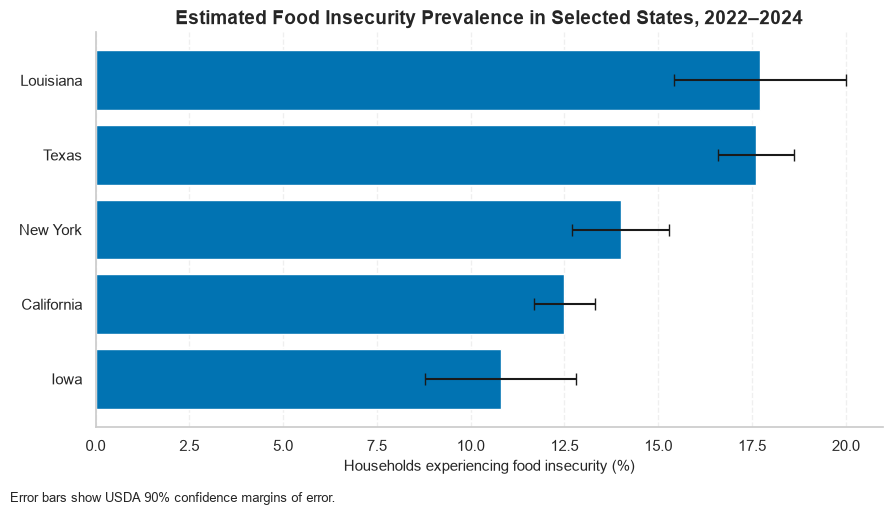

In [105]:
latest_state_plot_df = latest_state_comparison_df.copy()

latest_state_plot_df['state_name'] = (
    latest_state_plot_df['geography']
    .map(state_name_map)
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    y=latest_state_plot_df['state_name'],
    width=latest_state_plot_df['food_insecurity_prevalence'],
    xerr=latest_state_plot_df['food_insecurity_margin_of_error'],
    capsize=4,
    color=sns.color_palette('colorblind')[0]
)

ax.invert_yaxis()

ax.set(
    title='Estimated Food Insecurity Prevalence in Selected States, 2022–2024',
    xlabel='Households experiencing food insecurity (%)',
    ylabel=''
)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

fig.text(
    0.01,
    -0.02,
    'Error bars show USDA 90% confidence margins of error.',
    fontsize=9
)

ax.yaxis.grid(False)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Louisiana and Texas formed the highest-estimate group among the five selected states in 2022–2024. Their estimates, 17.7% and 17.6% respectively, were very similar when accounting for their margins of error, so Louisiana should not be interpreted as clearly higher than Texas. Both states’ uncertainty ranges were above those of California and Iowa. New York occupied an intermediate position, while California and Iowa had the two lowest point estimates; however, uncertainty makes the exact ordering among New York, California, and Iowa less definitive. Overall, the clearest pattern is that Louisiana and Texas had higher estimated food insecurity prevalence than California and Iowa.

#### 8.1.2 Historical Comparison

In [106]:
historical_state_comparison_df = (
    state_us_analysis_df.loc[
        state_us_analysis_df['geography'] != 'U.S. total',
        [
            'year',
            'period_end_year',
            'geography',
            'food_insecurity_prevalence',
            'food_insecurity_margin_of_error',
            'very_low_food_security_prevalence',
            'very_low_food_security_margin_of_error'
        ]
    ]
    .sort_values(
        ['geography','period_end_year']
    )
    .reset_index(drop=True)
)

historical_prevalence_table = (
    historical_state_comparison_df
    .pivot(
        index=['period_end_year', 'year'],
        columns='geography',
        values='food_insecurity_prevalence'
    )
    .sort_index()
    .droplevel('period_end_year')
    .rename(columns=state_name_map)
)

display(historical_prevalence_table)

geography,California,Iowa,Louisiana,New York,Texas
year,,,,,
2006–2008,12.0,11.6,11.0,11.3,16.3
2007–2009,14.1,11.5,10.0,12.4,17.4
2008–2010,15.9,12.1,12.6,12.9,18.8
2009–2011,16.2,12.0,14.1,13.3,18.5
2010–2012,15.6,12.6,15.7,13.2,18.4
2011–2013,15.0,11.9,16.5,14.0,18.0
2012–2014,13.5,11.4,17.6,14.4,17.2
2013–2015,12.6,10.6,18.4,14.1,15.4
2014–2016,11.8,10.7,18.3,12.5,14.3


In [107]:
print('Shape:', historical_state_comparison_df.shape)
print(
    'Rows per state:',
    historical_state_comparison_df
    .groupby('geography')
    .size()
)
print(
    'Period end-year range:',
    historical_state_comparison_df['period_end_year'].min(),
    'to',
    historical_state_comparison_df['period_end_year'].max()
)
print(
    'Missing values:',
    historical_state_comparison_df.isna().sum().sum()
)
print(
    'Duplicate state-period pairs:',
    historical_state_comparison_df.duplicated(
        subset=['geography', 'year']
    ).sum()
)

assert historical_state_comparison_df.shape == (85, 7)
assert set(historical_state_comparison_df['geography']) == expected_states
assert (
    historical_state_comparison_df
    .groupby('geography')
    .size()
    .eq(17)
    .all()
)
assert historical_state_comparison_df['period_end_year'].min() == 2008
assert historical_state_comparison_df['period_end_year'].max() == 2024
assert not historical_state_comparison_df.isna().any().any()
assert not historical_state_comparison_df.duplicated(
    subset=['geography', 'year']
).any()

Shape: (85, 7)
Rows per state: geography
CA    17
IA    17
LA    17
NY    17
TX    17
dtype: int64
Period end-year range: 2008 to 2024
Missing values: 0
Duplicate state-period pairs: 0


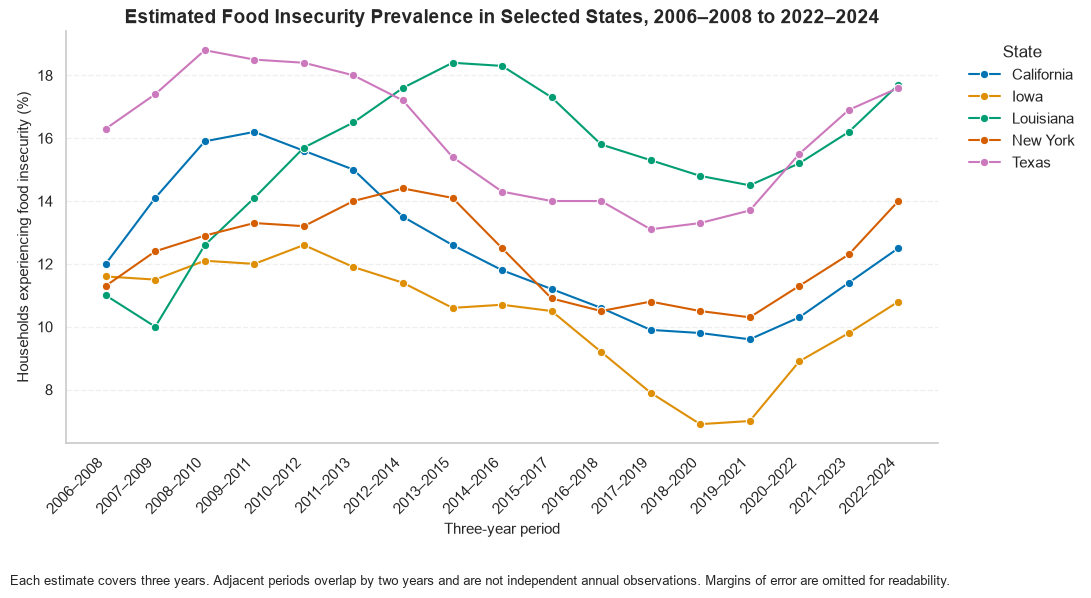

In [108]:
historical_state_plot_df = historical_state_comparison_df.copy()

historical_state_plot_df['state_name'] = (
    historical_state_plot_df['geography']
    .map(state_name_map)
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(
    data=historical_state_plot_df,
    x='period_end_year',
    y='food_insecurity_prevalence',
    hue='state_name',
    hue_order=state_order,
    palette=state_palette,
    marker='o',
    errorbar=None,
    ax=ax
)

period_labels = (
    historical_state_plot_df[
        ['period_end_year', 'year']
    ]
    .drop_duplicates()
    .sort_values('period_end_year')
)

ax.set_xticks(period_labels['period_end_year'])

ax.set_xticklabels(
    period_labels['year'],
    rotation=45,
    ha='right'
)

ax.set(
    title=(
        'Estimated Food Insecurity Prevalence in Selected States, '
        '2006–2008 to 2022–2024'
    ),
    xlabel='Three-year period',
    ylabel='Households experiencing food insecurity (%)'
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.legend(
    title='State',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

ax.xaxis.grid(False)

ax.set_axisbelow(True)

fig.text(
    0.01,
    0.01,
    (
        'Each estimate covers three years. Adjacent periods overlap by two years '
        'and are not independent annual observations. Margins of error are '
        'omitted for readability.'
    ),
    fontsize=9
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

plt.show()

Across all 17 overlapping three-year periods, the highest point estimate among the selected states was always recorded in either Texas or Louisiana. Texas had the highest point estimate during the first six periods, from 2006–2008 through 2011–2013. Louisiana then had the highest estimate from 2012–2014 through 2019–2021. Texas ranked highest again in 2020–2022 and 2021–2023, before Louisiana and Texas became nearly tied in 2022–2024. Iowa had the lowest point estimate in 15 of the 17 periods, while California and New York generally occupied intermediate positions. All five states had higher point estimates in 2022–2024 than in 2019–2021. Because adjacent periods overlap by two years and margins of error are not displayed on this chart, these findings describe broad patterns in the estimates rather than independent year-to-year changes or formal statistical differences.

### 8.2 State-to-U.S. Comparison

*How do selected states compare with the U.S. overall?*
- Use: `state_us_analysis_df`.
- Analysis: compare each selected state against `U.S. total`

### 8.3 Education Comparison

*How does food insecurity vary by education level in the U.S.?*
- Use: `educ_analysis_df`.
- Analysis: filter education rows + compare percentages

### 8.4 Employment Comparison

*How does food insecurity vary by employment group in the U.S.?*
- Use: `emp_analysis_df`.
- Analysis: filter employment rows + compare percentages

### 8.5 Disability Comparison

*How does food insecurity vary by disability status in the U.S.?*
- Use: `dis_analysis_df`
- Analysis: filter disability rows + compare percentages

### 8.6 World Bank Context

*How does the U.S. compare with Canada and Mexico on undernourishment, and what World Bank metadata can be used to interpret that comparison?*
- Use: `wb_context_df`
- Analysis: compare the U.S. with Canada and Mexico

#### 8.6.1 How does the U.S. compare with Canada and Mexico on undernourishment?

#### 8.6.2 What World Bank metadata can be used to interpret that comparison?

## 9. Conclusions

## 10. Limitations